In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


## Uppgift 15 – MNIST + prediktera egna handskrivna siffror

Tränar en modell på MNIST och bygger en preprocessing så att egna fotade siffror kan förutsägas. Huvudjobbet är **preprocessingen**: göra om ett foto (mörk siffra på ljust papper) till MNIST-format (28×28, ljus siffra på svart bakgrund, centrerad).

In [2]:
# Träna modell på MNIST (~55 MB första gången, cachas sen – kräver internet)
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
Xm, ym = mnist.data, mnist.target

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(Xm[:60000], ym[:60000])
print("Testaccuracy:", round(clf.score(Xm[60000:], ym[60000:]), 3))

Testaccuracy: 0.969


### Vilka siffror förväxlas? (confusion matrix)

Accuracy säger bara *hur ofta* modellen har rätt, inte *var* den går fel. Raderna är facit, kolumnerna gissningen, värdena andelar per rad. Eftersom diagonalen är ~0.97 dränker den allt annat – därför nollas den i högra panelen så att förväxlingsmönstret syns.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(ym[60000:], clf.predict(Xm[60000:]), normalize="true")
fel = cm.copy()
np.fill_diagonal(fel, 0)

fig, axar = plt.subplots(1, 2, figsize=(14, 6))
for ax, m, titel in zip(axar, (cm, fel), ("Alla andelar", "Endast förväxlingar")):
    ConfusionMatrixDisplay(m, display_labels=clf.classes_).plot(
        ax=ax, cmap="Blues", colorbar=(m is fel), values_format=".2f")
    ax.set_title(titel)
plt.tight_layout(); plt.show()


**Tolkning.** Felen är inte jämnt utspridda utan följer hur siffrorna ser ut. Vanligast är 4 → 9 och 7 → 2 (1,8 % vardera), sedan 5 → 3, 3 → 2 och 8 → 9. Det är just de par som delar form när slingan eller strecket skrivs slarvigt. 0 och 1 är däremot nästan aldrig fel – de liknar inget annat.


### Preprocessing – kärnan i uppgiften

Ett mobilfoto är stort, i färg och har mörk siffra på ljus bakgrund. MNIST är 28×28, gråskala, ljus siffra på svart, centrerad på tyngdpunkten. Funktionen nedan gör om det ena till det andra.

In [3]:
from pathlib import Path

from PIL import Image, ImageOps
from scipy.ndimage import center_of_mass, shift


def foto_till_mnist(bild, bakgrund=60):
    """Foto på en handskriven siffra -> 784 pixlar i MNIST-format.

    bakgrund = percentil som räknas som papper. Höj om pappret lyser igenom,
    sänk om delar av siffran försvinner (kalibreras per kamera/ljus).
    """
    a = np.asarray(ImageOps.grayscale(Image.open(bild) if isinstance(bild, (str, Path)) else bild), float)
    a = 255 - a                                            # mörk siffra på ljust papper -> ljus på svart
    a = np.clip(a - np.percentile(a, bakgrund), 0, None)   # bort med papper och skuggor
    a *= 255 / a.max()

    ys, xs = np.nonzero(a > 40)                            # beskär till siffran
    a = a[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

    h, w = a.shape                                         # längsta sidan -> 20 px, proportioner kvar
    s = 20 / max(h, w)
    liten = np.asarray(Image.fromarray(a.astype(np.uint8)).resize(
        (max(1, round(w * s)), max(1, round(h * s)))), float)

    ut = np.zeros((28, 28))                                # klistra in i 28x28 och centrera
    y0, x0 = (28 - liten.shape[0]) // 2, (28 - liten.shape[1]) // 2
    ut[y0:y0 + liten.shape[0], x0:x0 + liten.shape[1]] = liten
    cy, cx = center_of_mass(ut)                            # MNIST centrerar på tyngdpunkten
    return np.clip(shift(ut, (13.5 - cy, 13.5 - cx)), 0, 255).ravel()

### Kontroll utan mobil: simulerade "foton"

Innan man fotar 40 siffror är det bra att veta att preprocessingen faktiskt fungerar. Vi gör om MNIST-siffror till fejkfoton (mörk siffra på ljust papper, godtycklig storlek och placering), kör dem genom `foto_till_mnist` och ser om modellen fortfarande gissar rätt.

Träffsäkerhet på fejkfoton: 0.95


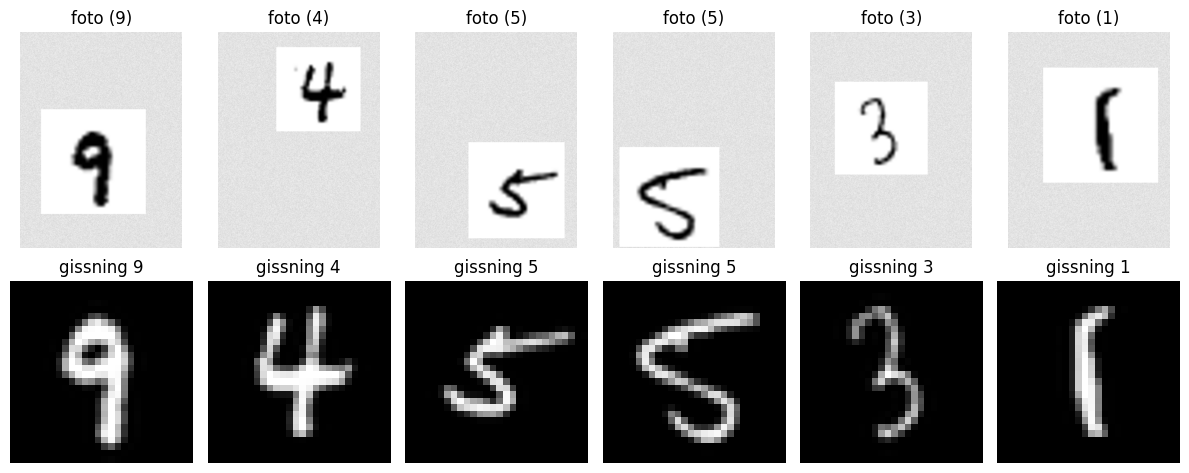

In [4]:
def fejkfoto(mnist_rad, rng):
    """MNIST-siffra -> 'mobilfoto': mörk siffra på ljust papper, slumpad storlek och placering."""
    img = Image.fromarray(255 - mnist_rad.reshape(28, 28).astype(np.uint8))
    img = img.resize((rng.integers(150, 260),) * 2)
    duk = Image.fromarray(rng.integers(215, 240, (400, 300), dtype=np.uint8))
    duk.paste(img, (rng.integers(0, 300 - img.width), rng.integers(0, 400 - img.height)))
    return duk


rng = np.random.default_rng(0)
idx = rng.choice(np.arange(60000, 70000), 40)
foton = [fejkfoto(Xm[i], rng) for i in idx]
pred = clf.predict(np.array([foto_till_mnist(f) for f in foton]))

traff = (pred == ym[idx]).mean()
print("Träffsäkerhet på fejkfoton:", traff)
assert traff > 0.8, "preprocessingen tappar information – kolla tröskel/centrering"

fig, axar = plt.subplots(2, 6, figsize=(12, 5))
for ax, f, i, p in zip(axar[0], foton, idx, pred):
    ax.imshow(f, cmap="gray"); ax.axis("off"); ax.set_title(f"foto ({ym[i]})")
for ax, f, p in zip(axar[1], foton, pred):
    ax.imshow(foto_till_mnist(f).reshape(28, 28), cmap="gray"); ax.axis("off"); ax.set_title(f"gissning {p}")
plt.tight_layout(); plt.show()

### Egna mobilbilder

Skriv siffror med tjock svart penna på vitt papper, en siffra per bild, fotografera rakt uppifrån i jämnt ljus och lägg bilderna i `exercises/egna_siffror/` (döp dem gärna till siffran de föreställer, t.ex. `7.jpg`).

In [5]:
filer = sorted(p for p in Path("egna_siffror").glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".heic"})
print(len(filer), "bilder")

if filer:
    bearbetade = np.array([foto_till_mnist(p) for p in filer])
    pred = clf.predict(bearbetade)

    fig, axar = plt.subplots(2, len(filer), figsize=(2 * len(filer), 5), squeeze=False)
    for i, (p, g) in enumerate(zip(filer, pred)):
        axar[0][i].imshow(Image.open(p), cmap="gray"); axar[0][i].set_title(p.stem)
        axar[1][i].imshow(bearbetade[i].reshape(28, 28), cmap="gray"); axar[1][i].set_title(f"gissning {g}")
        axar[0][i].axis("off"); axar[1][i].axis("off")
    plt.tight_layout(); plt.show()

    ratt = [p.stem for p in filer]                  # filnamn = facit
    if set(ratt) <= set(ym):
        print("Träffsäkerhet på egna bilder:", (pred == np.array(ratt)).mean())

0 bilder


**Slutsats.** Modellen är den enkla delen (random forest, ~97 % på MNIST) – hela jobbet ligger i att få ett foto att se ut som MNIST: invertera, tröskla bort pappret, beskära, skala till 20 px och centrera på tyngdpunkten. På simulerade foton behålls träffsäkerheten nästan helt, vilket visar att geometrin stämmer. Riktiga foton är svårare: ojämnt ljus, skuggor och tunn penna gör att `bakgrund`-tröskeln kan behöva justeras – det är precis den kalibrering som gör preprocessing icke-trivialt i verkligheten.